# OCR Plat Nomor Kendaraan menggunakan VLM (LM Studio + Python)

Notebook ini melakukan:
1. Download dataset & eksplorasi struktur
2. Inferensi OCR plat nomor pakai VLM via LM Studio (SDK resmi `lmstudio-python`)
3. Evaluasi hasil pakai Character Error Rate (CER)
4. Analisis contoh sukses & gagal

**Sebelum jalankan notebook ini:**
- Buka aplikasi **LM Studio** (bukan cuma install, harus dibuka/running)
- Di LM Studio, load model vision (mis. `qwen2-vl-2b-instruct`)
- Nyalakan Server di tab **Developer** LM Studio (status harus "Running")


## Step 0 — Install & Import semua library

Semua import ditaruh di satu cell paling awal, jadi cukup dijalankan sekali dan tidak perlu diulang di cell-cell berikutnya.

In [1]:
# %pip install lmstudio kagglehub pandas jiwer pillow  # uncomment kalau belum install

import os
import csv
import lmstudio as lms
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from jiwer import cer
from PIL import Image
from IPython.display import display
from IPython.display import clear_output

print("Semua library berhasil di-import")


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Semua library berhasil di-import


## Step 1 — Download dataset

Dataset diambil via `kagglehub`, otomatis ke-cache lokal (tidak perlu download manual, tidak perlu di-commit ke Git).

In [2]:
dataset_path = kagglehub.dataset_download("juanthomaswijaya/indonesian-license-plate-dataset")
print("Dataset ada di:", dataset_path)
print("Isi folder dataset:", os.listdir(dataset_path))


Dataset ada di: C:\Users\ASUS\.cache\kagglehub\datasets\juanthomaswijaya\indonesian-license-plate-dataset\versions\1
Isi folder dataset: ['Indonesian License Plate Dataset', 'Indonesian License Plate Recognition Dataset']


## Step 2 — Eksplorasi struktur dataset

Dataset ini punya 2 sub-folder utama. Yang dipakai adalah **"Indonesian License Plate Recognition Dataset"**
(sesuai soal: dataset "Indonesian License Plate Recognition", folder `test`).
Cell ini menampilkan sebagian isi folder `images/test` dan `labels/test`, plus isi 1 contoh file label
untuk mengecek formatnya (teks plat langsung, atau format YOLO bounding box).

**PENTING — cek output di atas sebelum lanjut:**
- Kalau isi file label berupa teks plat nomor langsung (mis. `B1234XYZ`) → lanjut ke Step 3, fungsi ground truth di bawah sudah pas.
- Kalau isinya format YOLO (angka-angka koordinat bounding box) → itu label untuk deteksi objek, bukan teks plat. Ganti path ke folder `labelswithLP` di dataset satunya (`Indonesian License Plate Dataset/labelswithLP/test`), lalu sesuaikan fungsi `read_ground_truth()` di Step 5.

In [3]:
TEST_IMAGE_FOLDER = os.path.join(dataset_path, "Indonesian License Plate Dataset", "images", "test")
TEST_LABEL_FOLDER = os.path.join(dataset_path, "Indonesian License Plate Dataset", "labelswithLP", "test")

image_files = sorted(os.listdir(TEST_IMAGE_FOLDER))
label_files = sorted(os.listdir(TEST_LABEL_FOLDER))

summary = pd.DataFrame({
    "Info": ["Jumlah gambar test", "Jumlah label test"],
    "Jumlah": [len(image_files), len(label_files)]
})
display(summary)

preview = pd.DataFrame({
    "Contoh gambar": image_files[:5],
    "Contoh label": label_files[:5]
})
display(preview)

print("=== Isi contoh file label (raw) ===")
for lbl in label_files[:3]:
    with open(os.path.join(TEST_LABEL_FOLDER, lbl)) as f:
        content = f.read()
    print(f"{lbl}: {repr(content)}")

,Info,Jumlah
0,Jumlah gambar test,100
1,Jumlah label test,100


,Contoh gambar,Contoh label
0,test001.jpg,test001.txt
1,test002.jpg,test002.txt
2,test003.jpg,test003.txt
3,test004.jpg,test004.txt
4,test005.jpg,test005.txt


=== Isi contoh file label (raw) ===
test001.txt: '0 0.23545 0.771991 0.074074 0.022156 B9140BCD\n0 0.472388 0.717593 0.050595 0.017857 B2407UZO\n0 0.780423 0.7333 0.062831 0.020833 B2842PKM\n'
test002.txt: '0 0.712467 0.664683 0.104828 0.040344 BG1352AE\n'
test003.txt: '0 0.186839 0.727513 0.064815 0.023148 B2634UZF\n0 0.761905 0.714286 0.106481 0.035714 B1995JVK\n'


## Step 3 — Cek koneksi ke LM Studio

Cell ini akan error kalau LM Studio belum running / server belum dinyalakan di tab Developer.

In [4]:
SERVER_API_HOST = "127.0.0.1:1234"
lms.configure_default_client(SERVER_API_HOST)  # panggil sekali saja, sebelum lms.llm()

MODEL_NAME = "qwen2-vl-2b-instruct"
model = lms.llm(MODEL_NAME)
print("Berhasil konek ke LM Studio, model aktif:", MODEL_NAME)


Berhasil konek ke LM Studio, model aktif: qwen2-vl-2b-instruct


## Step 4 — Fungsi ground truth, inferensi, dan cleaning teks

In [5]:
PROMPT = "What is the license plate number shown in this image? Respond only with the plate number."

def clean_text(text):
    return "".join(ch for ch in text.upper() if ch.isalnum())

def read_ground_truth(fname):
    label_path = os.path.join(TEST_LABEL_FOLDER, os.path.splitext(fname)[0] + ".txt")
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    if not lines:
        return ""
    return lines[0].split()[-1]

def predict_plate(image_path):
    img = Image.open(image_path)
    img.thumbnail((480, 480))
    tmp_path = "temp_resized.jpg"
    img.convert("RGB").save(tmp_path, quality=85)

    image_handle = lms.prepare_image(tmp_path)
    chat = lms.Chat()
    chat.add_user_message(PROMPT, images=[image_handle])
    prediction = model.respond(chat, config={"maxTokens": 25, "temperature": 0.1})
    return str(prediction).strip()

print("all functions defined successfully")

all functions defined successfully


In [6]:
import re

def extract_plate(text):
    text = text.upper()
    # cari pola mirip plat Indonesia: 1-2 huruf, 1-4 angka, 0-3 huruf
    matches = re.findall(r'[A-Z]{1,2}\d{1,4}[A-Z]{0,3}', text)
    if matches:
        return max(matches, key=len)  # ambil match terpanjang
    return text

def clean_text(text):
    return "".join(ch for ch in text.upper() if ch.isalnum())

## Step 5 — Jalankan inferensi ke semua gambar test

Loop ke semua gambar, print progress tiap gambar.

In [7]:
rows = []
errors = []
total = len(image_files)

for idx, fname in enumerate(image_files, start=1):
    if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    img_path = os.path.join(TEST_IMAGE_FOLDER, fname)

    try:
        gt = clean_text(read_ground_truth(fname))
    except Exception as e:
        gt = ""
        errors.append(f"GT gagal - {fname}: {e}")

    try:
        raw_pred = predict_plate(img_path)
        pred = clean_text(extract_plate(raw_pred))
    except Exception as e:
        pred = ""
        errors.append(f"Inferensi gagal - {fname}: {e}")

    rows.append([fname, gt, pred])

    if idx % 5 == 0 or idx == total:
        clear_output(wait=True)
        print(f"Progress: {idx}/{total} gambar")
        display(pd.DataFrame(rows, columns=["image", "ground_truth", "prediction"]).tail(10))

print(f"\nSelesai. Total gambar diproses: {len(rows)}")
if errors:
    print(f"{len(errors)} error ditemukan:")
    for e in errors[:10]:
        print(" -", e)

df_preview = pd.DataFrame(rows, columns=["image", "ground_truth", "prediction"])
display(df_preview)

Progress: 100/100 gambar


,image,ground_truth,prediction
90,test091.jpg,B2910KZW,B2910KZW
91,test092.jpg,B1104AAA,B108CA
92,test093.jpg,B2026BIU,B2028RII
93,test094.jpg,G1255EJ,G1255EJ
94,test095.jpg,B1201KAD,THELICENSEPLATENUMBERONTHEWHITECARIS3209KAA
95,test096.jpg,B1354COJ,THELICENSEPLATENUMBERONTHEWHITECARISNOTVISIBLE...
96,test097.jpg,B1650NOG,THELICENSEPLATENUMBERONTHEMOTORCYCLEISNOTVISIB...
97,test098.jpg,B1779DOB,B1779DOB
98,test099.jpg,B2017PBQ,B1892WZI
99,test100.jpg,B1071PRG,G3073PRG



Selesai. Total gambar diproses: 100


,image,ground_truth,prediction
0,test001.jpg,B9140BCD,B9140JN
1,test002.jpg,BG1352AE,BG1352AE
2,test003.jpg,B2634UZF,B1095JWK
3,test004.jpg,B9062VEH,THELICENSEPLATENUMBERONTHETRUCKINTHEIMAGEISNOT...
4,test005.jpg,DD8798KM,DD1798AKM
...,...,...,...
95,test096.jpg,B1354COJ,THELICENSEPLATENUMBERONTHEWHITECARISNOTVISIBLE...
96,test097.jpg,B1650NOG,THELICENSEPLATENUMBERONTHEMOTORCYCLEISNOTVISIB...
97,test098.jpg,B1779DOB,B1779DOB
98,test099.jpg,B2017PBQ,B1892WZI


## Step 6 — Simpan hasil mentah ke CSV

In [8]:
os.makedirs("results", exist_ok=True)
with open("results/raw_predictions.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image", "ground_truth", "prediction"])
    writer.writerows(rows)

print("Tersimpan di results/raw_predictions.csv")


Tersimpan di results/raw_predictions.csv


## Step 7 — Evaluasi CER (Character Error Rate)

CER = (S + D + I) / N, dihitung pakai `jiwer.cer` (berbasis Levenshtein distance).

In [9]:
def calc_cer(ground_truth, prediction):
    if len(ground_truth) == 0:
        return 1.0 if len(prediction) > 0 else 0.0
    return cer(ground_truth, prediction)

final_rows = []
for image, gt, pred in rows:
    score = round(calc_cer(gt, pred), 4)
    final_rows.append([image, gt, pred, score])

with open("results/prediction_results.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image", "ground_truth", "prediction", "CER_score"])
    writer.writerows(final_rows)

df = pd.DataFrame(final_rows, columns=["image", "ground_truth", "prediction", "CER_score"])
avg_cer = df["CER_score"].mean()
print(f"Rata-rata CER seluruh dataset: {avg_cer:.4f}")
df


Rata-rata CER seluruh dataset: 2.9818


,image,ground_truth,prediction,CER_score
0,test001.jpg,B9140BCD,B9140JN,0.375
1,test002.jpg,BG1352AE,BG1352AE,0.000
2,test003.jpg,B2634UZF,B1095JWK,0.875
3,test004.jpg,B9062VEH,THELICENSEPLATENUMBERONTHETRUCKINTHEIMAGEISNOT...,12.375
4,test005.jpg,DD8798KM,DD1798AKM,0.250
...,...,...,...,...
95,test096.jpg,B1354COJ,THELICENSEPLATENUMBERONTHEWHITECARISNOTVISIBLE...,7.625
96,test097.jpg,B1650NOG,THELICENSEPLATENUMBERONTHEMOTORCYCLEISNOTVISIB...,7.750
97,test098.jpg,B1779DOB,B1779DOB,0.000
98,test099.jpg,B2017PBQ,B1892WZI,0.875


## Step 8 — Analisis contoh sukses & gagal

3 contoh CER terendah (sukses) dan 3 contoh CER tertinggi (gagal), lengkap gambar, untuk bahan laporan.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14120\4248736088.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


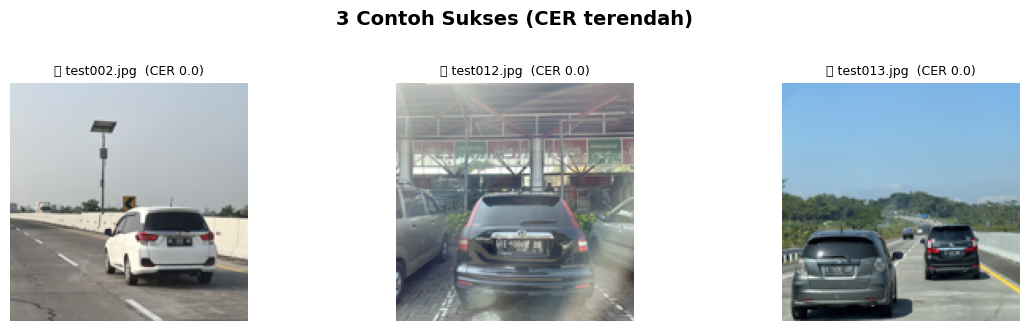

,image,ground_truth,prediction,CER_score
0,test002.jpg,BG1352AE,BG1352AE,0.0
1,test012.jpg,E1887BA,E1887BA,0.0
2,test013.jpg,B1439UZP,B1439UZP,0.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14120\4248736088.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


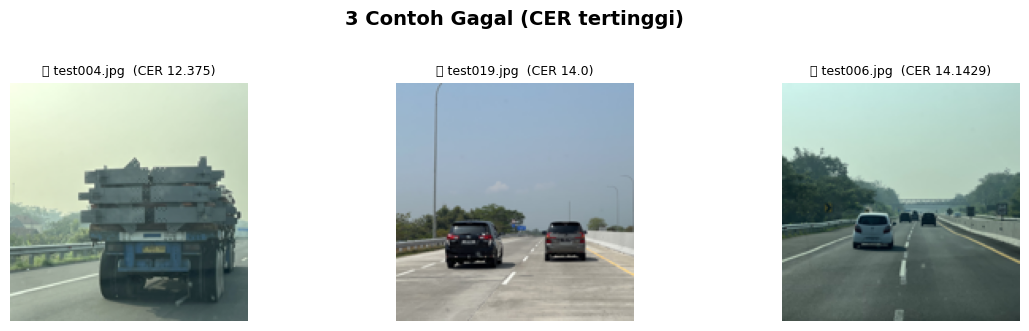

,image,ground_truth,prediction,CER_score
0,test004.jpg,B9062VEH,THELICENSEPLATENUMBERONTHETRUCKINTHEIMAGEISNOT...,12.3750
1,test019.jpg,AD7HS,THELICENSEPLATENUMBERONTHEBLACKCARISNOTCLEARLY...,14.0000
2,test006.jpg,T1329KC,THELICENSEPLATENUMBERONTHEWHITECARINTHEIMAGEIS...,14.1429


In [10]:
def show_examples_grid(title, subset):
    n = len(subset)
    cols = min(n, 3)
    rows = -(-n // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    axes = axes.flatten() if n > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < n:
            row = subset.iloc[i]
            img = Image.open(os.path.join(TEST_IMAGE_FOLDER, row["image"]))
            img.thumbnail((300, 150)) 
            ax.imshow(img)
            status = "✅" if row["CER_score"] < 0.2 else "❌"
            ax.set_title(f"{status} {row['image']}  (CER {row['CER_score']})", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

  
    display(subset[["image", "ground_truth", "prediction", "CER_score"]].reset_index(drop=True))

df_sorted = df.sort_values("CER_score")

show_examples_grid("3 Contoh Sukses (CER terendah)", df_sorted.head(3))
show_examples_grid("3 Contoh Gagal (CER tertinggi)", df_sorted.tail(3))

## Catatan penjelasan (isi manual untuk laporan)

- **Kenapa contoh sukses berhasil**: biasanya karena pencahayaan bagus, sudut kamera lurus, plat tidak kotor/blur.
- **Kenapa contoh gagal salah**: umumnya karena foto blur, sudut miring, pantulan cahaya, atau model tertukar membaca karakter mirip (0/O, 1/I, B/8, S/5).
- Isi bagian ini dengan observasi nyata dari hasil `df_sorted` di atas.
